<a href="https://colab.research.google.com/github/anamikasarker21/AI-ML/blob/main/MNIST_CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
import os
import cv2

In [ ]:
Train_data_path= '/content/drive/MyDrive/Digit_Detection/TrainingSet'
Test_data_path= "/content/drive/MyDrive/Digit_Detection/TestSet"

train_data=[]
train_label=[]
test_data=[]
test_label=[]


for label in range(10):
    # Load train
    folder = os.path.join(Train_data_path, str(label))
    for file in os.listdir(folder):
        img = cv2.imread(os.path.join(folder, file), cv2.IMREAD_GRAYSCALE)
        img = cv2.resize(img, (28, 28))
        train_data.append(img)
        train_label.append(label)

    # Load test
    folder = os.path.join(Test_data_path, str(label))
    for file in os.listdir(folder):
        img = cv2.imread(os.path.join(folder, file), cv2.IMREAD_GRAYSCALE)
        img = cv2.resize(img, (28, 28))
        test_data .append(img)
        test_label .append(label)
train_data= np.array(train_data)
train_label= np.array(train_label)
test_data= np.array(test_data)
test_label=np.array(test_label)

In [ ]:
train_data.shape
train_label.shape

(33617,)

In [ ]:
perm = np.random.permutation(len(train_data))
train_data = train_data[perm]
train_label = train_label[perm]

In [ ]:
train_data = train_data[:int(len(train_data) * 0.8)]
train_label = train_label[:int(len(train_label) * 0.8)]
valid_data= train_data[int(len(train_data) * 0.8):]
valid_label= train_label[int(len(train_label) * 0.8):]

In [ ]:
valid_data.shape

(5379, 28, 28)

In [ ]:
#normalise data
train_data = train_data / 255
valid_data= valid_data/255
test_data= test_data/255

In [ ]:
train_data.shape
valid_data.shape

(5379, 28, 28)

In [ ]:
test_data.shape

(8396, 28, 28)

In [ ]:
train_data.shape

(26893, 28, 28)

In [ ]:
import numpy as np
from keras.models import Sequential
from keras.layers import Dense, Dropout, BatchNormalization
from keras.utils import to_categorical
from keras import backend as K

# fix random seed for reproducibility
seed = 7
np.random.seed(seed)

train_label = to_categorical(train_label, num_classes=10) # 10 column for 10 number
valid_label = to_categorical(valid_label, num_classes=10) #10 column for 10 number
test_label = to_categorical(test_label, num_classes=10) #10 column for 10 number


#print shape
print("train_data shape: ",train_data.shape)
print("train_label shape: ",train_label.shape)
print("valid_data shape: ",valid_data.shape)
print("valid_label shape: ",valid_label.shape)
print("test_data shape: ",test_data.shape)
print("test_label shape: ",test_label.shape)

train_data shape:  (26893, 28, 28)
train_label shape:  (26893, 10)
valid_data shape:  (5379, 28, 28)
valid_label shape:  (5379, 10)
test_data shape:  (8396, 28, 28)
test_label shape:  (8396, 10)


In [ ]:
from keras.layers import Dense, Dropout, Flatten, Conv2D, MaxPooling2D

In [ ]:
# Define a function to create a model
def create_model():
    # create model
    model = Sequential()
    # Explicitly set data_format to 'channels_last' for Conv2D and MaxPooling2D, and updated input_shape
    model.add(Conv2D(32, (3, 3), input_shape=(28, 28, 1), activation='relu', data_format='channels_last'))
    model.add(MaxPooling2D(pool_size=(2, 2), data_format='channels_last'))
    model.add(Conv2D(64, (3, 3), activation='relu', data_format='channels_last'))
    model.add(MaxPooling2D(pool_size=(2, 2), data_format='channels_last'))
    model.add(Conv2D(128, (3, 3), activation='relu', data_format='channels_last'))
    # Removed MaxPooling2D layer here as it made the feature map too small
    model.add(Dropout(0.2))
    model.add(Conv2D(256, (3,3), activation='relu'))
    model.add(Dropout(0.2))
    model.add(Flatten())
    model.add(Dense(128, activation='relu'))
    model.add(Dense(10, activation='softmax'))
    # Compile model
    model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
    return model

In [ ]:
# build the model
model = create_model()
print(model.summary())

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_7 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 3, 3, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 3, 3, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 1, 1, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 1, 1, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 422,026 (1.61 MB)

 Trainable params: 422,026 (1.61 MB)

 Non-trainable params: 0 (0.00 B)

None


In [ ]:
# Fit the model
history_object = model.fit(train_data, train_label, validation_data=(valid_data, valid_label), epochs=25, batch_size=200, verbose=2)

Epoch 1/25
135/135 - 41s - 302ms/step - accuracy: 0.8407 - loss: 0.4914 - val_accuracy: 0.9662 - val_loss: 0.1112
Epoch 2/25
135/135 - 32s - 239ms/step - accuracy: 0.9687 - loss: 0.0989 - val_accuracy: 0.9859 - val_loss: 0.0492
Epoch 3/25
135/135 - 42s - 313ms/step - accuracy: 0.9798 - loss: 0.0637 - val_accuracy: 0.9870 - val_loss: 0.0396
Epoch 4/25
135/135 - 32s - 238ms/step - accuracy: 0.9840 - loss: 0.0508 - val_accuracy: 0.9937 - val_loss: 0.0219
Epoch 5/25
135/135 - 32s - 238ms/step - accuracy: 0.9862 - loss: 0.0405 - val_accuracy: 0.9924 - val_loss: 0.0232
Epoch 6/25
135/135 - 35s - 256ms/step - accuracy: 0.9898 - loss: 0.0308 - val_accuracy: 0.9952 - val_loss: 0.0174
Epoch 7/25
135/135 - 38s - 283ms/step - accuracy: 0.9903 - loss: 0.0291 - val_accuracy: 0.9963 - val_loss: 0.0130
Epoch 8/25
135/135 - 41s - 307ms/step - accuracy: 0.9925 - loss: 0.0244 - val_accuracy: 0.9961 - val_loss: 0.0114
Epoch 9/25
135/135 - 32s - 238ms/step - accuracy: 0.9920 - loss: 0.0230 - val_accuracy: 

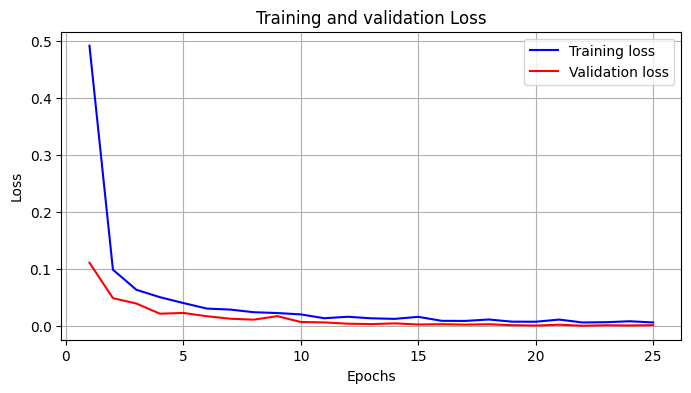

In [ ]:
import matplotlib.pyplot as plt

# Get training loss from history
train_loss = history_object.history['loss']
valid_loss=history_object.history['val_loss']
# Get number of epochs
epochs = range(1, len(train_loss) + 1)


# Plot both losses
plt.figure(figsize=(8, 4))
plt.plot(epochs, train_loss, 'b', label='Training loss')
plt.plot(epochs, valid_loss, 'r', label='Validation loss')
plt.title('Training and validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# Evaluate the model on the test data
scores = model.evaluate(test_data, test_label, verbose=0)
print("Accuracy on test data: %.2f%%" % (scores[1]*100))
print("Test loss: %.2f" % (scores[0]))

Accuracy on test data: 99.17%
Test loss: 0.04


In [ ]:
from keras.utils import to_categorical
test_label_one_hot = to_categorical(test_label, num_classes=10)
test_label_one_hot.shape

(8396, 10, 10)

In [ ]:
# Evaluate the model on the test data
scores = model.evaluate(test_data, test_label, verbose=0)
print("Accuracy on test data: %.2f%%" % (scores[1]*100))
print("Test loss: %.2f" % (scores[0]))

Accuracy on test data: 99.17%
Test loss: 0.04


In [ ]:
y_pred = np.argmax(model.predict(test_data), axis=1)

263/263 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step


In [ ]:
from sklearn.metrics import  confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

# Convert one-hot encoded test_label to integer labels
test_label_int = np.argmax(test_label, axis=1)

accuracy  = accuracy_score(test_label_int, y_pred)
precision = precision_score(test_label_int, y_pred, average='weighted', zero_division=0)
recall    = recall_score(test_label_int, y_pred, average='weighted')
f1        = f1_score(test_label_int, y_pred, average='weighted', zero_division=0)

print(f"Accuracy  : {accuracy  * 100:.2f}%")
print(f"Precision : {precision * 100:.2f}%")
print(f"Recall    : {recall    * 100:.2f}%")
print(f"F1 Score  : {f1        * 100:.2f}%")

Accuracy  : 99.17%
Precision : 99.17%
Recall    : 99.17%
F1 Score  : 99.17%


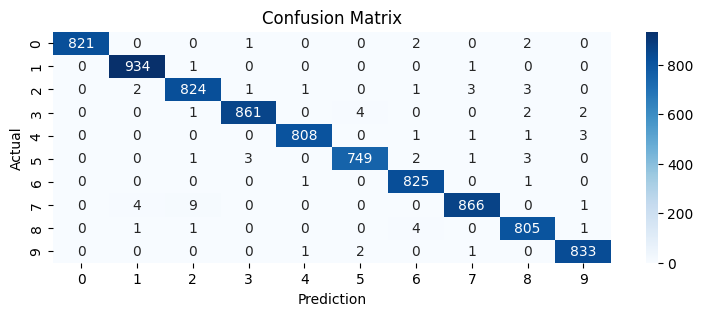

In [ ]:
y_true = test_label_int
confusionmatrics = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(9,3))
sns.heatmap(
    confusionmatrics,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=range(10),
    yticklabels=range(10)
)

plt.xlabel("Prediction")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()